# Подготовка данных

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
!pip install optuna
import optuna
from torchvision import datasets
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [49]:
# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 16

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = datasets.MNIST(root='data', train=True,
                                   download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False,
                                  download=True, transform=transform)

# prepare data loaders for stochastic gradient descent
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

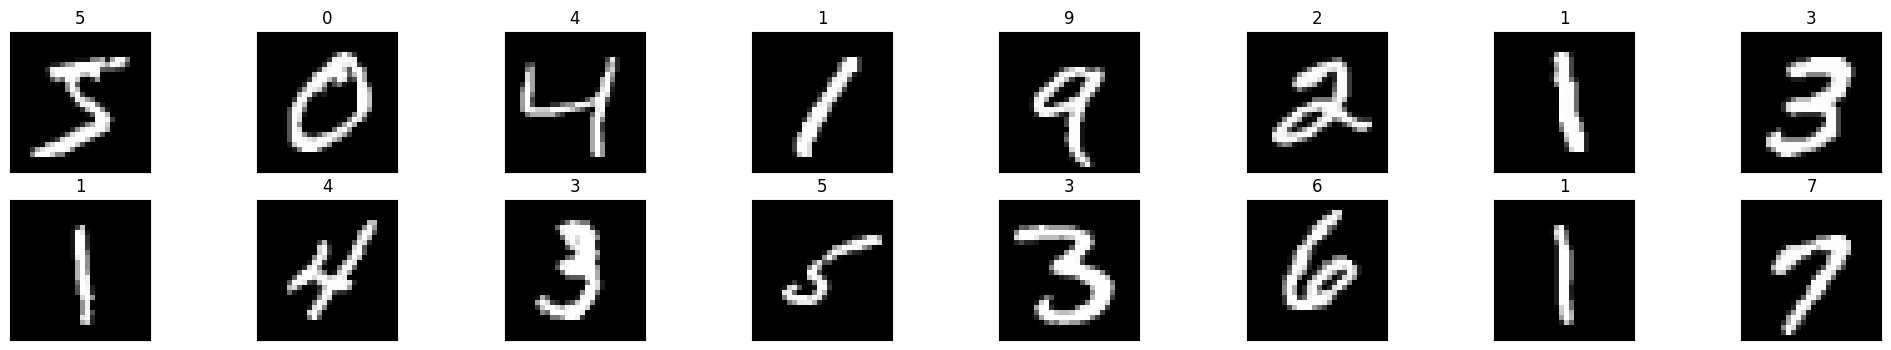

In [50]:
#%matplotlib inline
    
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(16):
    ax = fig.add_subplot(2, 16//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

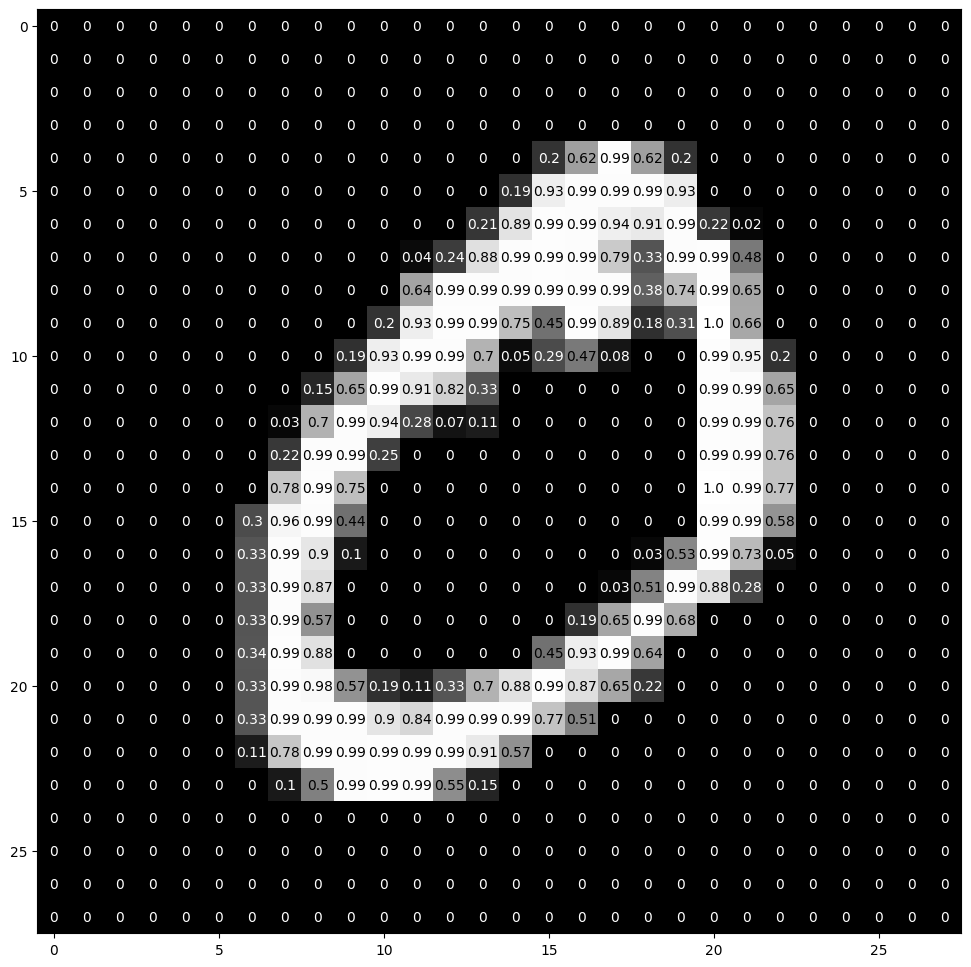

In [51]:
img = np.squeeze(images[1])

fig = plt.figure(figsize = (12,12)) 
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

# Тренировка + инференс

In [ ]:
class OptimizedNet(nn.Module):
    def __init__(self, hidden1, hidden2, dropout_rate):
        super(OptimizedNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 10)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

def train_model(model, train_loader, optimizer, criterion, device, epochs=1):
    model.train()
    for epoch in range(epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100.0 * correct / total

#зачем подбирать гиперпараметры ручками, когда есть optuna
def objective(trial):
    hidden1 = trial.suggest_int('hidden1', 256, 1024, step=128)
    hidden2 = trial.suggest_int('hidden2', 256, 1024, step=128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    n_epochs = trial.suggest_int('n_epochs', 5, 20)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])
    use_scheduler = trial.suggest_categorical('use_scheduler', [True, False])
    
    train_loader_opt = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, num_workers=0, shuffle=True
    )
    test_loader_opt = torch.utils.data.DataLoader(
        test_data, batch_size=batch_size, num_workers=0
    )
    
    model = OptimizedNet(hidden1, hidden2, dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        momentum = trial.suggest_float('momentum', 0.5, 0.99)
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    best_acc = 0
    for epoch in range(n_epochs):
        train_model(model, train_loader_opt, optimizer, criterion, device, epochs=1)
        if scheduler:
            scheduler.step()
        acc = evaluate_model(model, test_loader_opt, device)
        best_acc = max(best_acc, acc)
        
        if acc >= 99.0:
            trial.set_user_attr('early_stop', True)
            return acc
    
    return best_acc

In [53]:
study = optuna.create_study(direction='maximize', study_name='mnist_optimization')
print("Начинаем оптимизацию гиперпараметров...")
print("Цель: достичь accuracy >= 99%")
print("=" * 60)

study.optimize(objective, n_trials=20, timeout=3600, show_progress_bar=True)

print("\n" + "=" * 60)
print("Оптимизация завершена!")
print(f"Лучший trial: {study.best_trial.number}")
print(f"Лучшая accuracy: {study.best_trial.value:.4f}%")
print("\nЛучшие гиперпараметры:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

best_params = study.best_trial.params
print("\nОбучаем финальную модель с лучшими гиперпараметрами...")

best_batch_size = best_params['batch_size']
best_n_epochs = best_params.get('n_epochs', 15)
use_scheduler = best_params.get('use_scheduler', False)

final_train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=best_batch_size, num_workers=0, shuffle=True
)
final_test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=best_batch_size, num_workers=0
)

final_model = OptimizedNet(
    best_params['hidden1'], 
    best_params['hidden2'], 
    best_params['dropout_rate']
).to(device)

criterion = nn.CrossEntropyLoss()

if best_params['optimizer'] == 'Adam':
    final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
else:
    momentum = best_params.get('momentum', 0.9)
    final_optimizer = torch.optim.SGD(
        final_model.parameters(), 
        lr=best_params['lr'], 
        momentum=momentum
    )

final_scheduler = None
if use_scheduler:
    final_scheduler = torch.optim.lr_scheduler.StepLR(final_optimizer, step_size=5, gamma=0.5)

print(f"Обучение на {best_n_epochs} эпохах...")
best_acc = 0
for epoch in range(best_n_epochs):
    train_model(final_model, final_train_loader, final_optimizer, criterion, device, epochs=1)
    if final_scheduler:
        final_scheduler.step()
    acc = evaluate_model(final_model, final_test_loader, device)
    best_acc = max(best_acc, acc)
    if (epoch + 1) % 5 == 0 or acc >= 99.0:
        print(f"Эпоха {epoch + 1}/{best_n_epochs}, Accuracy: {acc:.2f}%")
    if acc >= 99.0:
        print(f"Достигнута цель 99% на эпохе {epoch + 1}!")
        break

final_accuracy = evaluate_model(final_model, final_test_loader, device)
print(f"\nФинальная accuracy: {final_accuracy:.4f}%")

[I 2025-12-01 18:58:16,543] A new study created in memory with name: mnist_optimization


Начинаем оптимизацию гиперпараметров...
Цель: достичь accuracy >= 99%


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-12-01 19:00:17,276] Trial 0 finished with value: 94.62 and parameters: {'hidden1': 256, 'hidden2': 640, 'dropout_rate': 0.4, 'lr': 0.0009392498657614658, 'batch_size': 64, 'n_epochs': 14, 'optimizer': 'SGD', 'use_scheduler': False, 'momentum': 0.8697757653381468}. Best is trial 0 with value: 94.62.
[I 2025-12-01 19:01:47,516] Trial 1 finished with value: 39.69 and parameters: {'hidden1': 256, 'hidden2': 256, 'dropout_rate': 0.2, 'lr': 0.00047898044161897435, 'batch_size': 256, 'n_epochs': 12, 'optimizer': 'SGD', 'use_scheduler': True, 'momentum': 0.5345283067641332}. Best is trial 0 with value: 94.62.
[I 2025-12-01 19:03:54,556] Trial 2 finished with value: 47.36 and parameters: {'hidden1': 1024, 'hidden2': 384, 'dropout_rate': 0.30000000000000004, 'lr': 0.08958140027847108, 'batch_size': 128, 'n_epochs': 16, 'optimizer': 'Adam', 'use_scheduler': False}. Best is trial 0 with value: 94.62.
[I 2025-12-01 19:05:32,124] Trial 3 finished with value: 98.52 and parameters: {'hidden1':

In [54]:
final_model.eval()
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for data, target in final_test_loader:
        data, target = data.to(device), target.to(device)
        output = final_model(data)
        loss = criterion(output, target)
        test_loss += loss.item() * data.size(0)
        _, pred = torch.max(output, 1)
        correct = pred.eq(target.data.view_as(pred))
        for i in range(len(target)):
            label = target.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

test_loss = test_loss / len(final_test_loader.dataset)
print(f'Test Loss: {test_loss:.6f}\n')

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            int(class_correct[i]), int(class_total[i])))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    int(np.sum(class_correct)), int(np.sum(class_total))))

Test Loss: 0.063068

Test Accuracy of     0: 99% (973/980)
Test Accuracy of     1: 99% (1128/1135)
Test Accuracy of     2: 98% (1014/1032)
Test Accuracy of     3: 98% (996/1010)
Test Accuracy of     4: 98% (963/982)
Test Accuracy of     5: 97% (874/892)
Test Accuracy of     6: 98% (946/958)
Test Accuracy of     7: 98% (1011/1028)
Test Accuracy of     8: 98% (960/974)
Test Accuracy of     9: 98% (990/1009)

Test Accuracy (Overall): 98% (9855/10000)


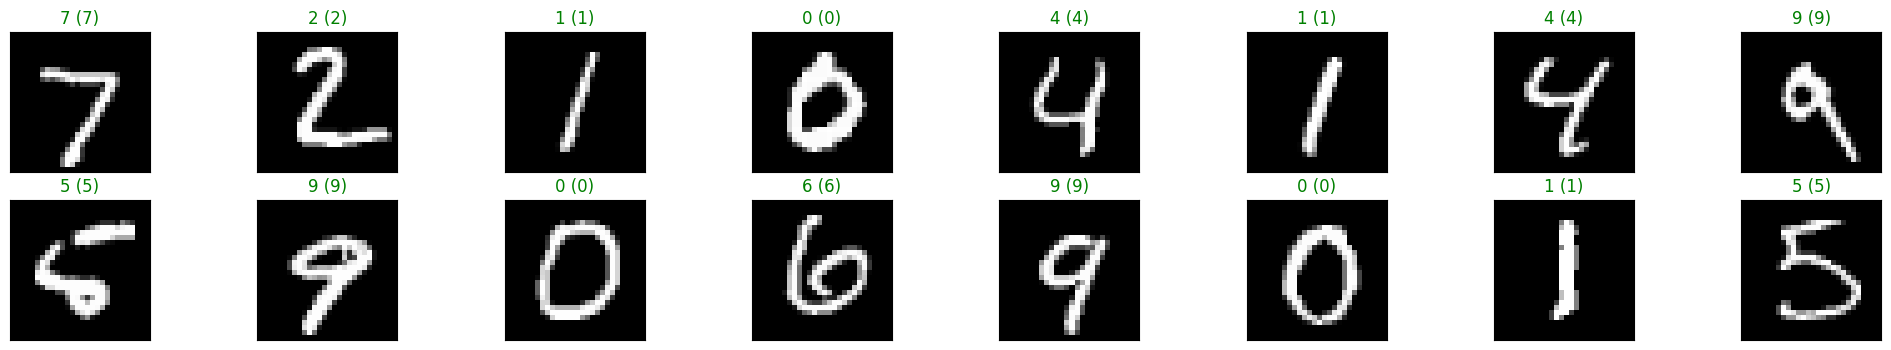

In [55]:
dataiter = iter(final_test_loader)
images, labels = next(dataiter)

final_model.eval()
with torch.no_grad():
    images_gpu = images.to(device)
    output = final_model(images_gpu)
    _, preds = torch.max(output, 1)
    preds = preds.cpu()

images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(min(16, len(images))):
    ax = fig.add_subplot(2, 16//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

# Метрики качества

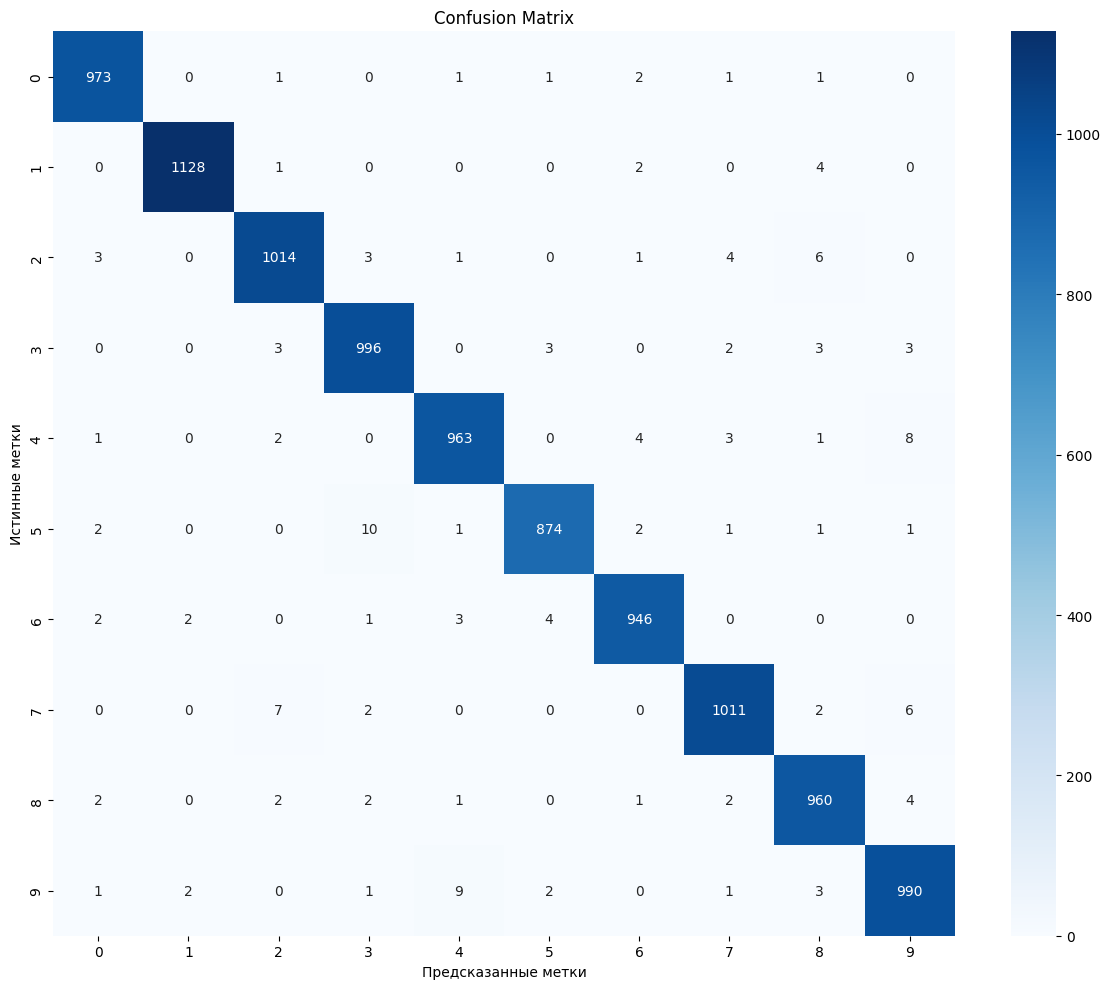

Общая Accuracy модели: 0.9855 (98.55%)

Метрики для цифры 5:
  True Positives: 874
  False Positives: 10
  False Negatives: 18
  True Negatives: 9098

  Precision: 0.9887 (98.87%)
  Recall: 0.9798 (97.98%)
  Accuracy для цифры 5: 0.9972 (99.72%)
  F1-score: 0.9842 (98.42%)


In [68]:
final_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, target in final_test_loader:
        data, target = data.to(device), target.to(device)
        output = final_model(data)
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(target.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.tight_layout()
plt.show()

digit = 5

overall_accuracy = accuracy_score(all_labels, all_preds)
print(f"Общая Accuracy модели: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")

precision = precision_score(all_labels, all_preds, labels=[digit], average='macro', zero_division=0)
tp = cm[digit, digit]  # TP
fp = cm[:, digit].sum() - tp  # FP
fn = cm[digit, :].sum() - tp  # FN
tn = cm.sum() - tp - fp - fn  # TN

precision_digit = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_digit = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy_digit = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

print(f"\nМетрики для цифры {digit}:")
print(f"  True Positives: {tp}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Negatives: {tn}")
print(f"\n  Precision: {precision_digit:.4f} ({precision_digit*100:.2f}%)")
print(f"  Recall: {recall_digit:.4f} ({recall_digit*100:.2f}%)")
print(f"  Accuracy для цифры {digit}: {accuracy_digit:.4f} ({accuracy_digit*100:.2f}%)")

f1_score = 2 * (precision_digit * recall_digit) / (precision_digit + recall_digit) if (precision_digit + recall_digit) > 0 else 0
print(f"  F1-score: {f1_score:.4f} ({f1_score*100:.2f}%)")

# Бонус: ROC AUC

/tmp/ipython-input-2068704539.py:44: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



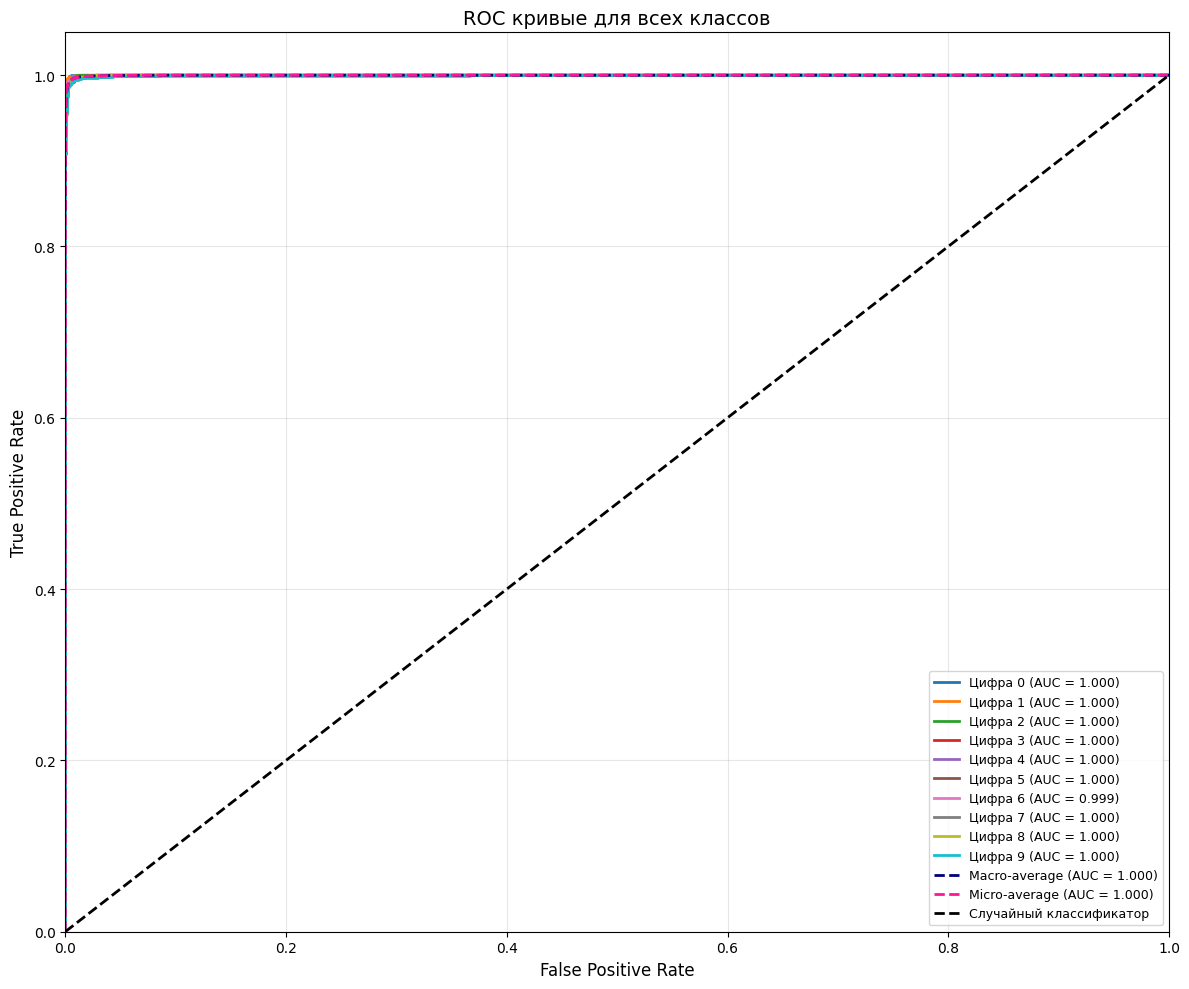


AUC для каждого класса:
  Цифра 0: 1.0000
  Цифра 1: 0.9999
  Цифра 2: 0.9999
  Цифра 3: 0.9998
  Цифра 4: 0.9998
  Цифра 5: 0.9999
  Цифра 6: 0.9995
  Цифра 7: 0.9998
  Цифра 8: 0.9998
  Цифра 9: 0.9997

Macro-averaged AUC: 0.9998
Micro-averaged AUC: 0.9998

ROC AUC (one-vs-rest, macro): 0.9998
ROC AUC (one-vs-one, macro): 0.9998


In [66]:
final_model.eval()
all_probs = []
all_labels_probs = []

with torch.no_grad():
    for data, target in final_test_loader:
        data, target = data.to(device), target.to(device)
        output = final_model(data)
        probs = F.softmax(output, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels_probs.extend(target.cpu().numpy())

all_probs = np.array(all_probs)
all_labels_probs = np.array(all_labels_probs)

y_test_bin = label_binarize(all_labels_probs, classes=range(10))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-averaged ROC AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 10

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Micro-averaged ROC AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(12, 10))

# ROC by class
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, 10))
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Цифра {i} (AUC = {roc_auc[i]:.3f})')

# Macro-averaged ROC
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle='--', linewidth=2)

# Micro-averaged ROC
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle='--', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC кривые для всех классов', fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC для каждого класса:")
for i in range(10):
    print(f"  Цифра {i}: {roc_auc[i]:.4f}")

print(f"\nMacro-averaged AUC: {roc_auc['macro']:.4f}")
print(f"Micro-averaged AUC: {roc_auc['micro']:.4f}")

roc_auc_ovr = roc_auc_score(all_labels_probs, all_probs, multi_class='ovr', average='macro')
roc_auc_ovo = roc_auc_score(all_labels_probs, all_probs, multi_class='ovo', average='macro')
print(f"\nROC AUC (one-vs-rest, macro): {roc_auc_ovr:.4f}")
print(f"ROC AUC (one-vs-one, macro): {roc_auc_ovo:.4f}")
